In [ ]:
from datetime import datetime
from meteostat import Point, Daily
import pandas as pd

# Współrzędne geograficzne Des Moines, Iowa
latitude = 41.5868
longitude = -93.6250
elevation = 277  # wysokość nad poziomem morza w metrach

# Okres czasu
start = datetime(2010, 1, 1)
end = datetime(2024, 12, 31)

# Utwórz obiekt Point
location = Point(latitude, longitude, elevation)

# Pobierz dane dzienne
data = Daily(location, start, end)
df = data.fetch()

# Zapisz dane do pliku CSV
df.to_csv('iowa_weather_data.csv', index=True)

print(df.head())


Pobieranie danych pogodowych dla Iowa...
  Zapisano D:\marcinszwagrzyk.github.io\Soy\data\weather\Iowa_weather.csv
Pobieranie danych pogodowych dla Illinois...
  Zapisano D:\marcinszwagrzyk.github.io\Soy\data\weather\Illinois_weather.csv
Pobieranie danych pogodowych dla Minnesota...


  Zapisano D:\marcinszwagrzyk.github.io\Soy\data\weather\Minnesota_weather.csv
Pobieranie danych pogodowych dla Indiana...


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x00000142DF88A650>>
Traceback (most recent call last):
  File "c:\Users\Airly\anaconda3\envs\GeoPython_Ukraine2024_v2\lib\site-packages\ipykernel\ipkernel.py", line 783, in _clean_thread_parent_frames
    if phase != "start":
KeyboardInterrupt: 


  Zapisano D:\marcinszwagrzyk.github.io\Soy\data\weather\Indiana_weather.csv
Pobieranie danych pogodowych dla Nebraska...


C:\Users\Airly\AppData\Local\Temp\ipykernel_5300\3810695496.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clim['clim_precip_std'].fillna(1.0,inplace=True)
C:\Users\Airly\AppData\Local\Temp\ipykernel_5300\3810695496.py:127: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', len(years))


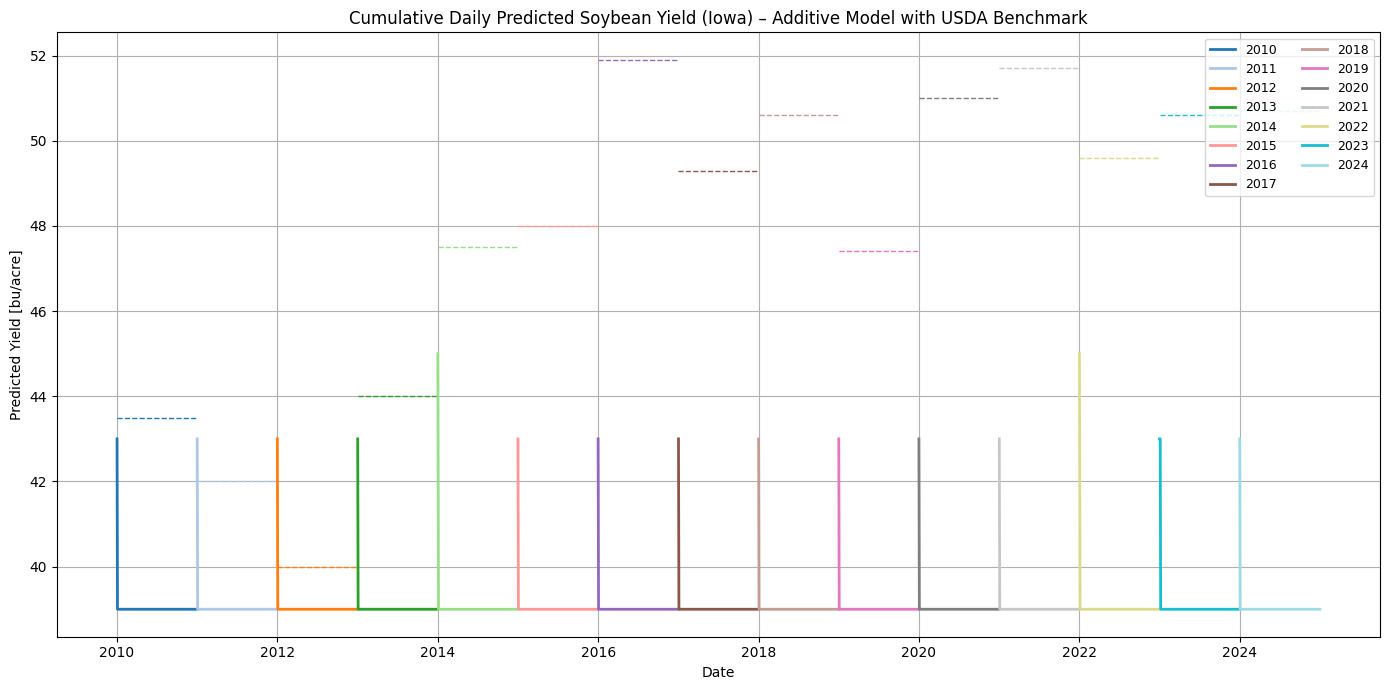

In [2]:
#!/usr/bin/env python3
"""
Cumulative daily soybean yield forecast (Iowa) – multi-year additive model with benchmark
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------
# 0. Parameters
# -----------------------------
YIELD_MIN = 35
YIELD_MAX = 55

PLANTING_DATE = "05-01"
PREPLANT_DAYS = 60
DROUGHT_WINDOW = 30

# Sensitivity parameters (can be tuned)
drought_sensitivity = 1.0
preplant_sensitivity = 1.0
heat_wave_sensitivity = 1.0
cold_sensitivity = 1.0
excess_rain_sensitivity = 1.0

# -----------------------------
# 1. Load weather CSV
# -----------------------------
input_csv = "iowa_weather_data.csv"  # user-provided CSV
df_weather = pd.read_csv(input_csv)
df_weather = df_weather.rename(columns={'time':'date', 'prcp':'precip_mm'})
df_weather['date'] = pd.to_datetime(df_weather['date'])
df_weather['year'] = df_weather['date'].dt.year
df_weather['tmean'] = (df_weather['tmin'] + df_weather['tmax']) / 2.0
df_weather['location'] = 'Iowa'
df_weather['doy'] = df_weather['date'].dt.dayofyear

# -----------------------------
# 2. USDA benchmark yields (Midwest)
# -----------------------------
benchmark_usda = {
    2010:43.5, 2011:42.0, 2012:40.0, 2013:44.0, 2014:47.5,
    2015:48.0, 2016:51.9, 2017:49.3, 2018:50.6, 2019:47.4,
    2020:51.0, 2021:51.7, 2022:49.6, 2023:50.6, 2024:50.7
}

# -----------------------------
# 3. Compute daily cumulative yield (additive)
# -----------------------------
def compute_daily_yield(df):
    df = df.copy()
    daily_forecast = []

    # Climatology
    clim = df.groupby('doy').agg(
        clim_precip_mean=('precip_mm','mean'),
        clim_precip_std=('precip_mm','std'),
        clim_tmean_mean=('tmean','mean')
    ).reset_index()
    clim['clim_precip_std'].fillna(1.0,inplace=True)
    clim_map = clim.set_index('doy')

    for yr, sub in df.groupby('year'):
        sub = sub.sort_values('date')
        sub = sub.set_index('date')
        planting_date = pd.to_datetime(f"{yr}-{PLANTING_DATE}")
        planting_date = max(min(planting_date, sub.index.max()-pd.Timedelta(days=30)), sub.index.min()+pd.Timedelta(days=30))

        # Preplant window (average conditions)
        pre_start = planting_date - pd.Timedelta(days=PREPLANT_DAYS)
        pre_end = planting_date - pd.Timedelta(days=1)
        pre = sub.loc[(sub.index>=pre_start) & (sub.index<=pre_end)]
        pre_mean_t = pre['tmean'].mean() if not pre.empty else clim_map['clim_tmean_mean'].mean()
        pre_total_precip = pre['precip_mm'].sum() if not pre.empty else clim_map['clim_precip_mean'].sum()
        # preplant risk (normalized)
        preplant_risk = preplant_sensitivity * np.clip(0.5*(pre_mean_t-clim_map['clim_tmean_mean'].mean())/10 - 0.5*(pre_total_precip-clim_map['clim_precip_mean'].sum())/100, 0,0.5)

        # Start cumulative index
        cum_index = 1.0 - preplant_risk
        cum_index = np.clip(cum_index,0.2,1.0)

        for dt, row in sub.iterrows():
            doy = row['doy']
            clim_precip = clim_map.loc[doy,'clim_precip_mean']
            clim_std = clim_map.loc[doy,'clim_precip_std'] if clim_map.loc[doy,'clim_precip_std']>0 else 1
            daily_z = (row['precip_mm'] - clim_precip)/clim_std

            # Drought penalty
            drought_pen = np.clip(drought_sensitivity * (-daily_z if daily_z<0 else 0), 0, 0.1)

            # Heat penalty (critical period mid-July to mid-August)
            heat_pen = 0
            if 180<=doy<=227 and row['tmax']>32:
                heat_pen = heat_wave_sensitivity*0.05

            # Cold penalty early summer
            cold_pen = 0
            if 120<=doy<=160 and row['tmin']<5:
                cold_pen = cold_sensitivity*0.05

            # Excess rain penalty
            excess_pen = excess_rain_sensitivity * 0.05 if row['precip_mm']>25 else 0

            # Additive update
            daily_adjustment = -(drought_pen + heat_pen + cold_pen + excess_pen)
            cum_index += daily_adjustment
            cum_index = np.clip(cum_index,0.2,1.0)

            predicted_yield = YIELD_MIN + cum_index*(YIELD_MAX - YIELD_MIN)
            daily_forecast.append({'date':dt,'year':yr,'predicted_yield_bu_ac':predicted_yield,'cum_index':cum_index})

    return pd.DataFrame(daily_forecast)

# -----------------------------
# 4. Compute
# -----------------------------
df_daily_all = compute_daily_yield(df_weather)
df_daily_all.to_csv("iowa_soy_cumulative_all_years.csv", index=False)

# -----------------------------
# 5. Plot multi-year
# -----------------------------
plt.figure(figsize=(14,7))
years = sorted(df_daily_all['year'].unique())
colors = cm.get_cmap('tab20', len(years))
for i, yr in enumerate(years):
    df_plot = df_daily_all[df_daily_all['year']==yr]
    plt.plot(df_plot['date'], df_plot['predicted_yield_bu_ac'], color=colors(i), lw=2, label=str(yr))
    # benchmark USDA
    if yr in benchmark_usda:
        plt.hlines(benchmark_usda[yr], df_plot['date'].min(), df_plot['date'].max(), color=colors(i), lw=1, ls='--')

plt.title("Cumulative Daily Predicted Soybean Yield (Iowa) – Additive Model with USDA Benchmark")
plt.xlabel("Date")
plt.ylabel("Predicted Yield [bu/acre]")
plt.grid(True)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()
